## Hidden Markov Model

Markets exhibit periods with disticnt behaviour and characteristics, these patterns are commonly refered to as market regimes. Market regimes are not directly defined or observable, however identifying these persistent changes in market behaviour can be useful for investment and risk-management decisions. For example, characteristics of a "crisis" market regime could be characterized by extreme volatility, large  absolute returns and persistant negative trends. Identifying such regimes could provide additional information about the current level of market risk.

Market regimes can be described as latent states that can't be observed directly. A Hidden Markov Model (HMM) provides a probabilistic framework that can be used to find hidden states through observable market data. The implied regimes depend strongly on the information provided to the model. The initial specification in this notebook uses three features: daily log returns, momentum, and conditional volatility estimated by the GARCH(1,1) model. 

The objective of this notebook is to evaluate whether the implemented HMM can identify persistent and economically interpretable market regimes, and then investigate how the model specification affects the resulting regime classification.

In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t, norm
import statsmodels.api as smapi
import statsmodels as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

project_root = Path.cwd().parent


if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    

In [20]:
from src import data_loader as dl
from src import preprocessing as pp
from src import garch
from src import features
from src.markov_model.hmm import HiddenMarkovModel as hmm
from sklearn.preprocessing import StandardScaler

# Download S&P 500 data from 2000-01-01 and compute daily log returns.
raw_data = dl.load_market_data()
market_data = pp.preprocess_market_data(raw_data)
garch_output = garch.fit_garch(market_data["Return"]*100)

## Data & baseline features 

The initial dataset is the S&P 500 market/price data spaning from 2000-01-01 through present date. This dataset is utilized to construct the baseline features, which include daily log returns, a 20-day momentum window, and conditional volatility extracted from a GARCH(1,1) model. To prevent overfitting and the introduction of unnecessary noise, it is preferable to train the Hidden Markov Model (HMM) on a limited set of distinct features initially. Starting with a parsimonious feature set limits model complexity and provides an interpretable baseline from which additional features can later be evaluated.

These baseline features capture distinct market dynamics: daily log returns capture the direction and magnitude of short-term price changes, momentum captures trend behavior, and conditional volatility serves as a proxy for current market risk. Finally, the dataset is partitioned chronologically, reserving the first 70% of the observations for in-sample training and the remaining 30% for out-of-sample evaluation.

### Descriptive Statistics of Training Set

In [18]:
hmm_features = features.build_hmm_features(market_data, garch_output)
split_idx = int(len(hmm_features) * 0.70)

train_df = hmm_features.iloc[:split_idx]
test_df = hmm_features.iloc[split_idx:]

X_train = train_df#.to_numpy()
X_test = test_df#.to_numpy()

X_train.describe()
#X_train.corr()

,Returns,Momentum_20,Conditional_Volatility
count,4671.000000,4671.000000,4671.000000
mean,0.000153,0.002962,0.010693
std,0.012034,0.045729,0.006157
min,-0.094695,-0.330730,0.003936
25%,-0.004812,-0.017549,0.006756
50%,0.000545,0.009952,0.008992
75%,0.005644,0.029227,0.012635
max,0.109572,0.211030,0.058756


### Discussion 

The baseline features exhibit noticeably different statistical properties and scales. Momentum has the largest variance, with a standard deviation of approximately 0.046, compared with 0.012 for daily log returns and 0.006 for conditional volatility. Both returns and momentum take positive and negative values and are centered relatively close to zero, whereas conditional volatility is strictly positive and centered around 0.011. Conditional volatility also exhibits a smaller variation relative to its mean. These differences suggest that the features capture different aspects of market behaviour, however the differences in scale should be considered when specifying the HMM.

### Correlation Matrix of Training Set

In [19]:
X_train.corr()

,Returns,Momentum_20,Conditional_Volatility
Returns,1.000000,0.215945,0.001051
Momentum_20,0.215945,1.000000,-0.444580
Conditional_Volatility,0.001051,-0.444580,1.000000


### Discussion

The correlation matrix exhbits no linnear correlation (0.001) between daily returns and conditional volatility, not out of character since volatility describes uncertainty in the market rather than direction. Momentum and returns have a weak positive correlation (0.216), which is reasonable since the daily return is part of the current momentum window. The strongest relationship is observed between momentum and conditional volatility, with a correlation of -0.445. This indicates that periods of elevated conditional volatility tend to exhibit weaker momentum, demonstrating the combination of negative trends and elevated volatility often observed during periods of market stress.

### Feature Scaling

The baseline features have different numerical scales, which can affect the KMeans initialization of the HMM. Therefore, the features are standardized to have zero mean and unit variance. To prevent data leakage, the scaler is fitted exclusively on the training data and then applied to the test data using the same transformation.

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Means:", X_train.mean(axis=0))
print("Standard deviations:", X_train.std(axis=0))

Means: [0.00000000e+00 2.43388649e-17 0.00000000e+00]
Standard deviations: [1. 1. 1.]


## Baseline HMM

The baseline Hidden Markov Model is specified with three hidden states, creating a model that can distinguish between different market conditions while keeping it initialy relatively simple. A full covariance structure is used, this to allow the model to capture dependencies between the standardized log returns, 20-day momentum, and conditional volatility features.

The model is trained on the first 70% of the observations using a chronological split, while the remaining 30% is reserved for out-of-sample evaluation. Model parameters are initialized using KMeans clustering before being iteratively estimated using the Baum–Welch algorithm. Training continues until the change in log-likelihood falls below the convergence tolerance of $10^{−5}$, or until the maximum of 100 iterations is reached.

This specification serves as the baseline model. The number of states, covariance structure, and feature specification will be evaluated and compared in later sections rather than assumed to be optimal.

In [27]:
HMM = hmm(feature_matrix = X_train, states = 3, covariance_type = "full").fit()

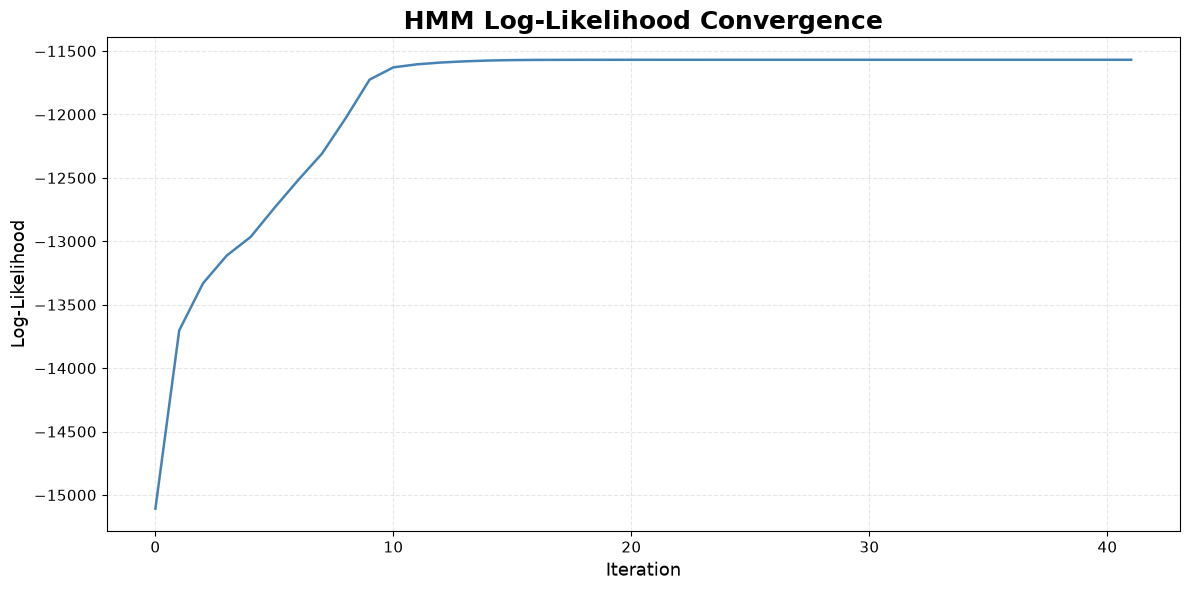

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(
    HMM.log_likelihood_history,
    linewidth=1.8,
    color="steelblue"
)

plt.title(
    "HMM Log-Likelihood Convergence",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Iteration", fontsize=13)
plt.ylabel("Log-Likelihood", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.3)
plt.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.show()